
# Lab6A: Dyna-Q and Figure 8.2 in [Sutton & Barto]

This lab reproduces **Figure 8.2** from *Reinforcement Learning: An Introduction*
(Sutton & Barto, Chapter 8).

We study **Dyna-Q** in a simple deterministic maze and analyze how the number of
planning steps `n` affects learning speed, measured in **steps per episode**.

You will:
- Build the **Dyna Maze** (47 states)
- Implement a **Dyna-Q algorithm**
- Reproduce the learning curves for `n = 0, 5, 50`
- Understand *why* planning accelerates learning

---



## 1. Experimental setup

- Discount factor: $\gamma = 0.95$
- Learning rate: $\alpha = 0.1$
- Exploration: $\varepsilon = 0.1$ for $\varepsilon$-greedy.
- Reward:
  - `+1` when entering the goal state
  - `0` otherwise
- Environment:
  - Deterministic transitions
  - Grid world with obstacles (47 states total)

These choices match the RL book setup for Figure 8.2 in [Sutton & Barto].


In [2]:
from dataclasses import dataclass
from typing import ClassVar

import matplotlib.pyplot as plt
import numpy as np


**Exercise 1.** (The Dyna Maze Environment) Implement the maze used in Figure 8.2 and understand the code.

The maze:
- Is a 6×9 grid (54 cells)
- Contains **7 obstacles**, leaving **47 valid states**
- Has four actions: up, right, down, left
- If an action would hit a wall or obstacle, the agent **stays in place**
- Reward is +1 **only when entering the goal cell**



*Hints.*

- Use a `(row, col) -> state_id` mapping
- Obstacles can be stored as a `set` of coordinates


In [3]:
@dataclass  # is the class header and automatically generates an __init__ for you using the annotated fields (rows, cols, gamma).
class DynaMazeEnv:
    """A simple gridworld maze environment for Dyna-Q experiments, matching Figure 8.2 in Sutton and Barto.

    Args:
        rows (int): number of rows in the maze grid
        cols (int): number of columns in the maze grid
        gamma (float): discount factor for future rewards

    """

    rows: int = (
        6  # Default maze size is 6x9, matching the maze used in Figure 8_2 example
    )
    cols: int = 9
    gamma: float = 0.95  # discount factor

    action_moves: ClassVar[dict[int, tuple[int, int]]] = {
        0: (-1, 0),  # up
        1: (0, 1),  # right
        2: (1, 0),  # down
        3: (0, -1),  # left
    }

    def __post_init__(self) -> None:
        """__post_init__ is called automatically after the dataclass __init__ method. It initializes the maze structure, walls, start/goal positions, and state mappings."""
        # 7 obstacles -> 54 - 7 = 47 states since
        # Total grid cells: 6 * 9 = 54
        # Wall cells: 7
        # Valid states: 54 - 7 = 47

        self.walls = set()  # self.walls stores blocked cells (walls) as (r, c) pairs.
        for r in [
            1,
            2,
            3,
        ]:  # This part creates the maze's “two vertical walls + one extra block” structure.
            self.walls.add((r, 2))
        for r in [0, 1, 2]:
            self.walls.add((r, 7))
        self.walls.add((4, 5))

        self.start_rc = (2, 0)  # Start is at row 2, col 0.
        self.goal_rc = (0, 8)  # Goal is at row 0, col 8.

        # Now we map (row,col) to state index
        self.rc_to_s = {}
        self.s_to_rc = {}
        s = 0
        for r in range(self.rows):  # Iterate through all cells
            for c in range(self.cols):
                if (
                    (r, c) in self.walls
                ):  # If the cell is a wall, skip it: walls are not states.
                    continue
                self.rc_to_s[(r, c)] = (
                    s  # Otherwise, rc_to_s[(r,c)] = s gives an integer label for this free cell.
                )
                self.s_to_rc[s] = (
                    r,
                    c,
                )  # s_to_rc[s] = (r,c) lets you recover the grid coordinate from a state id.
                s += 1  # s increments only for valid cells.

        assert s == 47, (  # noqa: PLR2004, S101
            f"Expected 47 states, got {s}"
        )  # The assert prevents silent bugs if walls are miscounted.
        self.n_states = s  # number of states
        self.n_actions = 4  # number of actions
        self.reset()  # self.reset() sets the initial state.

    def reset(self) -> int:
        """Reset the environment to the start state."""
        self.state = self.rc_to_s[self.start_rc]
        return self.state

    def step(self, action: int) -> tuple[int, float, bool]:
        """Take an action in the environment. Returns (next_state, reward, done)."""
        r, c = self.s_to_rc[
            self.state
        ]  # self.state is an integer, so we need to convert it to grid coordinate.
        dr, dc = self.action_moves[action]
        nr, nc = r + dr, c + dc  # Compute proposed next cell (nr, nc).

        if (  # Boundary + wall collision handling : If the agent try to go outside the grid or into a wall, the agent stays in place.
            nr < 0
            or nr >= self.rows
            or nc < 0
            or nc >= self.cols
            or (nr, nc) in self.walls
        ):
            nr, nc = r, c  # The agent should stay in the same place.

        next_state = self.rc_to_s[(nr, nc)]  # convert back to integer state
        reward = 1.0 if (nr, nc) == self.goal_rc else 0.0  # Reward: Goal = 1, other = 0
        done = (
            nr,
            nc,
        ) == self.goal_rc  # termination : Episode ends when goal is reached.
        self.state = next_state  # Update self.state
        return next_state, reward, done  # return transition tuple



**Exercise 2.** (Implement Dyna-Q) Implement a **tabular Dyna-Q algorithm**:

Algorithm structure:
1. Select action using $\varepsilon$-greedy with fair tie-breaking.
2. Take real step in environment
3. Q-learning update
4. Store transition in the model
5. Perform `n` planning updates by sampling from the model



### Hints

- Initialize all Q-values to zero
- Use a dictionary for the model: `(s, a) -> (r, s')`
- Planning updates are **identical** to Q-learning updates


In [4]:
def epsilon_greedy_action(
    Q_row: np.ndarray,
    eps: float,
    rng: np.random.Generator,
) -> int:
    """Implement an ε-greedy policy. Here, Q_row is the vector Q(s, .) for a fixed state s."""
    if rng.random() < eps:  # With probability epsilon: explore (choose a random action)
        return int(
            rng.integers(0, len(Q_row)),
        )  # With probability 1-ε: exploit (choose an action with the highest estimated value)
    maxv = np.max(Q_row)  # Finds the maximum Q-value among actions.
    best = np.flatnonzero(
        Q_row == maxv,
    )  #  here can be ties, means several actions have the same Q value,
    # Q_row == maxv gives a boolean array like [True, False, True, ...]
    # np.flatnonzero(...) returns the indices where it's True (a 1D array), e.g. [0, 2]
    return int(
        rng.choice(best),
    )  # If multiple best actions exist, pick one uniformly at random and this prevents a systematic bias like always choosing the smallest index action.


class DynaQAgent:
    """Now we define a learning agent that implements the Dyna-Q algorithm."""

    def __init__(  # noqa: PLR0913
        self,
        n_states: int,
        n_actions: int,
        alpha: float = 0.1,
        gamma: float = 0.95,
        eps: float = 0.1,
        planning_steps: int = 5,
        rng: np.random.Generator | None = None,
    ) -> None:
        """Initialize the Dyna-Q agent with parameters.

        Args:
            n_states (int): number of states in the environment
            n_actions (int): number of actions in the environment
            alpha (float): learning rate for Q-learning updates
            gamma (float): discount factor for future rewards
            eps (float): epsilon for epsilon-greedy action selection
            planning_steps (int): number of planning updates per real step
            rng (np.random.Generator, optional): random number generator for reproducibility

        """
        self.Q = np.zeros(
            (n_states, n_actions),
        )  # This is the aabular Q-learning table with rows = states and columns = actions,
        # Initially all values are 0
        self.alpha = alpha  # alpha = learning rate (step size) for Q updates.
        self.gamma = gamma  # gamma = discount factor used in TD target.
        self.eps = eps  # eps = epsilon for epsilon-greedy exploration.
        self.n = planning_steps  # This is the “n” in Dyna-Q: number of planning updates per real step.
        self.rng = (
            rng or np.random.default_rng()
        )  # If we provide a random generator, use it (for reproducibility), otherwise, creat a new one.

        self.model = {}  # This is the learned model is stored as a dictionary, with Key: (s, a) and value: (r, s'). Here we assume that the maze dynamics are deterministic.
        self.observed_sa = []  # A list of all (s,a) pairs that have been seen at least once.
        # Used so planning can sample only from experienced pairs (instead of impossible ones).

    def act(self, s: int) -> int:
        """Select an action using an ε-greedy policy based on the current Q-values."""
        return epsilon_greedy_action(
            self.Q[s],
            self.eps,
            self.rng,
        )  # self.Q[s] extracts the row vector Q(s, :) (the value of actions for state s) then we pass it to epsilon-greedy.

    def q_update(self, s: int, a: int, r: float, sp: int) -> None:
        """Perform a Q-learning update for a given transition."""
        td_target = r + self.gamma * np.max(self.Q[sp])  # sp here means s'
        self.Q[s, a] += self.alpha * (td_target - self.Q[s, a])  #  Q-learning update

    def observe(
        self,
        s: int,
        a: int,
        r: float,
        sp: int,
    ) -> None:
        """Observe a transition and update the agent's knowledge."""
        # Direct RL update
        self.q_update(
            s,
            a,
            r,
            sp,
        )  # Direct RL update : this is learning from real experience (interaction with the environment).

        # Model update = this is learning from simulated experience
        key = (s, a)  # key identifies the state-action pair.
        if key not in self.model:  # If this (s,a) has never been seen,
            self.observed_sa.append(
                key,
            )  # record it in observed_sa so planning can use it.
        self.model[key] = (
            r,
            sp,
        )  # Now we update the model : “If in state s take action a, we will get reward r and go to state sp.”

        # Planning = This is the “Dyna” part.
        for _ in range(self.n):  # for each planning step (n steps in total)
            ss, aa = self.observed_sa[
                int(self.rng.integers(len(self.observed_sa)))
            ]  # Sample a previously observed (s,a) pair uniformly at random
            rr, ssp = self.model[
                (ss, aa)
            ]  # Use the model to retrieve its predicted reward and next state (rr, ssp). Hint. use self.model[key], what is the key here ?
            self.q_update(
                ss,
                aa,
                rr,
                ssp,
            )  # Apply the same Q-learning update as if it were a real transition. Hint. use self.q_update(ss, aa, rr, ssp)


**Exercise 3.** Reproduce Figure 8.2

Run the experiment:
- 50 episodes
- Average over 30 independent runs
- Compare `n = 0`, `n = 5`, `n = 50`
- Plot **steps per episode vs episodes**



*Hints*

- Use the **same random seed across different `n` values** for each repetition
- Episode 1 should be identical for all `n`


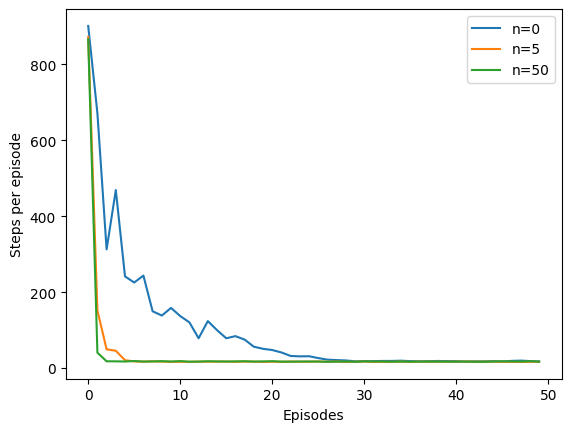

In [5]:
def run_episodes(
    env: DynaMazeEnv,
    planning_steps: int,
    episodes: int = 50,
    seed: int = 0,
) -> np.ndarray:
    """Run one experiment of Dyna-Q on a given environment, for a fixed number of episodes and planning steps.

    Args:
        env (DynaMazeEnv): the maze environment
        planning_steps (int): the Dyna parameter n = number of model/planning updates per real step.
        episodes (int, optional): number of episodes to run. Defaults to 50.
        seed (int, optional): random seed for reproducibility. Defaults to 0.

    """
    rng = np.random.default_rng(
        seed,
    )  # create a random number generator for reproducibility
    agent = DynaQAgent(
        env.n_states, env.n_actions, planning_steps=planning_steps, rng=rng,
    )  # Initializes a new Dyna-Q agent with:
    # Q-table size (n_states, n_actions)
    # planning_steps = the Dyna parameter n = number of model/planning updates per real step.
    # rng for reproducibility

    steps_per_episode = []  # This will store one integer per episode: the number of steps until reaching goal.

    for _ in range(episodes):  # Loop episodes
        s = env.reset()  # Reset the environment at the start for each episode
        done = False  # done is the terminal indicator from the environment, it is false at the beginning
        steps = 0  # steps counts how many environment interactions happen this episode.
        while not done:  # interaction until terminal
            a = agent.act(s)  # Choose action using epsilon-greedy policy
            sp, r, done = env.step(
                a,
            )  # this is the environment transition: sp = next state s'; r = reward ; done = whether goal reached.
            agent.observe(
                s, a, r, sp,
            )  # This is the whole Dyna update : the agent will learn from this real transition + plan from model
            s = sp  # this line advances state variable, now sp becomes the current state
            steps += 1  # add + 1 into the step counter
        steps_per_episode.append(steps)  # Store episode length after reaching the goal

    return np.array(steps_per_episode)  # return the number of step as NumPy array


def replicate_figure() -> None:
    """Run multiple independent experiments and plot averages for different planning steps n."""
    env = DynaMazeEnv()  # call the environment
    ns = [
        0,
        5,
        50,
    ]  # These are different values of Dyna-Q planning step where 0 = pure Q-learning (no planning)
    runs = 30  # runs: number of independent experimental runs (different seeds)
    episodes = 50  # episodes: number of episodes per run
    results = {n: [] for n in ns}  # Storage dictionary, which creates a dictionary like

    for rep in range(runs):  # Run experiments
        seed = rep  # TO DO # choose seeds, what is your stratgy to choose different seed ? Hint. for each rep, we need to choose different seed.
        for (
            n
        ) in ns:  # Inner loop: compare different planning values using the same seed
            env = DynaMazeEnv()  # call a new environment for this condition
            results[n].append(
                run_episodes(env, n, episodes, seed),
            )  # run_episodes creates a new agent and runs 50 episodes, returns an array of length 50
            # Append that array into results[n]

    avg = {
        n: np.mean(results[n], axis=0) for n in ns
    }  # results[n] is a list of arrays ; axis=0 means average over runs, for each episode index.

    for n in ns:  # Plots one curve per n with X-axis = episode number (0, ..., 49) and Y-axis = average steps to reach goal
        plt.plot(avg[n], label=f"n={n}")

    plt.xlabel("Episodes")
    plt.ylabel("Steps per episode")
    plt.legend()
    plt.show()


replicate_figure()


**Exercise 4.**  How and why does increasing the planning step `n` speed up learning?


More planning steps -> more simulated Q-updates per real step -> faster

value propagation -> improved sample efficiency (fewer real interactions).